In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [47]:
df = pd.read_excel("supervised_artifacts/labeled_predictions.xlsx")

In [48]:
# ===== CHỌN FEATURE ĐỂ CLUSTER =====
features = [
    "price", "discount_percent_clean", "rating_average", "quantity_sold_value",
    "brand_le", "seller_id_le"
]
X = df[features].copy()

In [49]:
# ===== CHUẨN HÓA =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

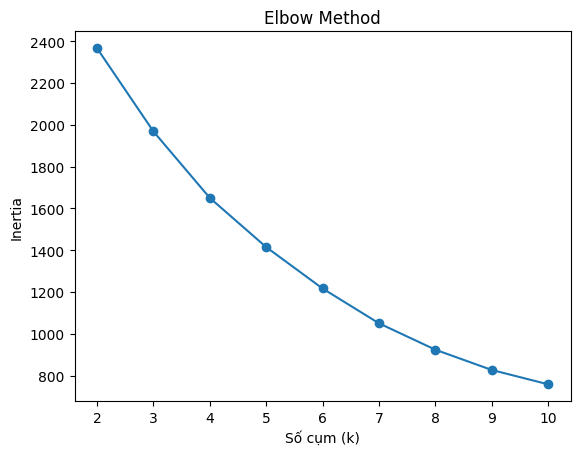

In [50]:
# ===== TÌM SỐ CỤM TỐI ƯU (Elbow) =====
inertia = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.xlabel("Số cụm (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Biểu đồ Elbow cho thấy khi số cụm tăng từ 2 lên 4, giá trị inertia giảm mạnh (từ khoảng 2400 xuống 1600). Tuy nhiên, từ k=5 trở đi, mức giảm inertia không còn nhiều, đường cong trở nên thoải dần. Do đó, điểm gấp khúc (“elbow”) xuất hiện tại k=4. Vì vậy, ta chọn số cụm tối ưu là 4 cụm để vừa đảm bảo phân chia hợp lý, vừa tránh phân cụm quá nhỏ lẻ.

In [51]:
# ===== CLUSTERING VỚI K SỐ CỤM (ví dụ k=4) =====
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df["cluster_id"] = kmeans.fit_predict(X_scaled)

In [52]:
# ===== ĐÁNH GIÁ CLUSTER =====
sil_score = silhouette_score(X_scaled, df["cluster_id"])
print(f"Silhouette Score = {sil_score:.3f}")

Silhouette Score = 0.290


Sau khi chọn số cụm tối ưu k=4 theo phương pháp Elbow, nhóm tính chỉ số Silhouette Score = 0.290.
Kết quả này cho thấy các cụm đã hình thành nhưng chưa có sự tách biệt rõ ràng, một số cụm vẫn còn chồng chéo về đặc trưng. Tuy nhiên, với dữ liệu sản phẩm vốn đa dạng và có nhiều yếu tố nhiễu (giá, thương hiệu, mức giảm giá, số lượng bán…), việc đạt được chỉ số khoảng 0.29 vẫn có thể chấp nhận được để tiến hành phân tích phân khúc.

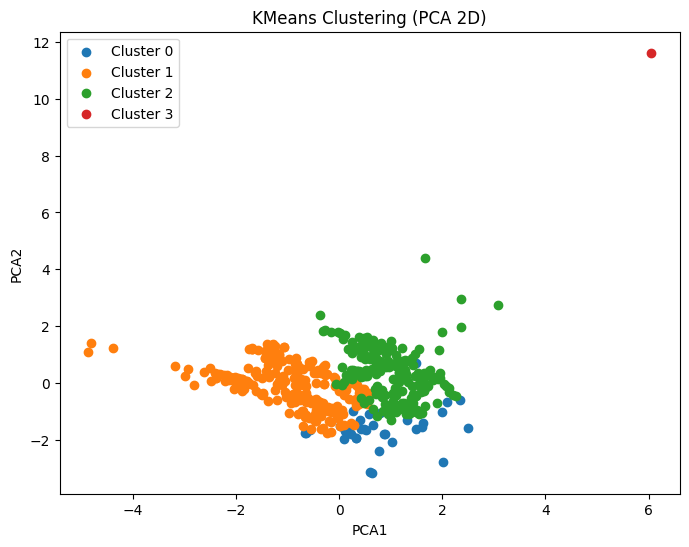

In [53]:
# ===== GIẢM CHIỀU PCA VÀ VẼ BIỂU ĐỒ =====
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df["pca1"] = X_pca[:,0]
df["pca2"] = X_pca[:,1]

plt.figure(figsize=(8,6))
for c in range(k_opt):
    plt.scatter(df[df["cluster_id"]==c]["pca1"],
                df[df["cluster_id"]==c]["pca2"],
                label=f"Cluster {c}")
plt.legend()
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("KMeans Clustering (PCA 2D)")
plt.show()

In [54]:
df.to_excel("processing_data_2.xlsx", index=False)
print("[INFO] Đã lưu processing_data_2.xlsx")

[INFO] Đã lưu processing_data_2.xlsx
